## **Stack Overflow Developer Survey 2020**

Stack Overflow her yıl, çoğunlukla yazılım geliştiricileri olan kullanıcılarına, Stack Overflow'u nasıl kullandıkları, işleri ve kullandıkları geliştirme araçları hakkında anket yapar. Şimdi, Veri Bilimcileri olarak tanımlanan kullanıcıların anket yanıtlarının bir alt kümesine bakacağız.

**z-scores**

Değişkenler keyfi birimlere ve aralıklara sahip olduğundan, hipotez test edilmeden önce değerlerin standartlaştırılması gerekir. Değerleri standartlaştırmanın yaygın bir yolu ortalamayı çıkarmak ve standart sapmaya bölmektir. Hipotez testi için, örnek istatistiğin alındığı, varsayılan parametre değerinin çıkarıldığı ve standart hataya bölündüğü bir varyasyon kullanılır. Sonuç z-skoru olarak adlandırılır.

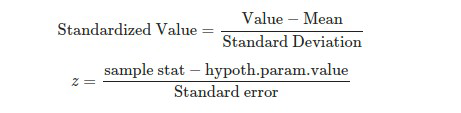


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df_stck = pd.read_feather("resources/stack_overflow.feather")
df_stck

,respondent,main_branch,hobbyist,age,age_1st_code,age_first_code_cut,comp_freq,comp_total,converted_comp,country,...,survey_length,trans,undergrad_major,webframe_desire_next_year,webframe_worked_with,welcome_change,work_week_hrs,years_code,years_code_pro,age_cat
0,36.0,"I am not primarily a developer, but I write co...",Yes,34.0,30.0,adult,Yearly,60000.0,77556.0,United Kingdom,...,Appropriate in length,No,"Computer science, computer engineering, or sof...",Express;React.js,Express;React.js,Just as welcome now as I felt last year,40.0,4.0,3.0,At least 30
1,47.0,I am a developer by profession,Yes,53.0,10.0,child,Yearly,58000.0,74970.0,United Kingdom,...,Appropriate in length,No,"A natural science (such as biology, chemistry,...",Flask;Spring,Flask;Spring,Just as welcome now as I felt last year,40.0,43.0,28.0,At least 30
2,69.0,I am a developer by profession,Yes,25.0,12.0,child,Yearly,550000.0,594539.0,France,...,Too short,No,"Computer science, computer engineering, or sof...",Django;Flask,Django;Flask,Just as welcome now as I felt last year,40.0,13.0,3.0,Under 30
3,125.0,"I am not primarily a developer, but I write co...",Yes,41.0,30.0,adult,Monthly,200000.0,2000000.0,United States,...,Appropriate in length,No,None,None,None,Just as welcome now as I felt last year,40.0,11.0,11.0,At least 30
4,147.0,"I am not primarily a developer, but I write co...",No,28.0,15.0,adult,Yearly,50000.0,37816.0,Canada,...,Appropriate in length,No,"Another engineering discipline (such as civil,...",None,Express;Flask,Just as welcome now as I felt last year,40.0,5.0,3.0,Under 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2256,62812.0,I am a developer by profession,Yes,40.0,10.0,child,Yearly,145000.0,145000.0,United States,...,Too long,No,"Computer science, computer engineering, or sof...",Flask;jQuery,Angular;Angular.js;Flask;jQuery;React.js,Somewhat less welcome now than last year,50.0,30.0,20.0,At least 30
2257,62835.0,I am a developer by profession,Yes,23.0,9.0,child,Monthly,180000.0,33972.0,Russian Federation,...,Too short,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET Core;Flask,Just as welcome now as I felt last year,60.0,8.0,3.0,Under 30
2258,62837.0,I am a developer by profession,Yes,27.0,8.0,child,Monthly,7500.0,97284.0,Germany,...,Appropriate in length,No,Mathematics or statistics,None,None,Just as welcome now as I felt last year,42.0,12.0,2.0,Under 30
2259,62867.0,"I am not primarily a developer, but I write co...",Yes,33.0,13.0,child,Monthly,6000.0,72000.0,Panama,...,Too long,No,"Another engineering discipline (such as civil,...",None,Django;React.js,A lot less welcome now than last year,45.0,15.0,2.0,At least 30


In [2]:
first_code_boot_distn = []

for _ in range(5000):
    first_code_boot_distn.append(
        np.mean(
            (df_stck.sample(frac=1, replace=True)
            ['age_first_code_cut'] == 'child').mean()
        )
    )

In [3]:
prop_child_samp = (df_stck['age_first_code_cut'] == 'child').mean()
prop_child_samp

0.39141972578505085

In [4]:
prop_child_hyp = 0.35

In [5]:
std_err = np.std(first_code_boot_distn, ddof=1)
std_err

0.010242297036767876

In [6]:
z_score = (prop_child_samp - prop_child_hyp) / std_err
z_score

4.043987948832379

**Calculating the p-value**

z-skoru, varsayılan sıfır ortalama ve bir standart sapma değerleriyle standart normal CDF'ye, norm.cdf()'ye aktarılır. Sol kuyruk testi değil, sağ kuyruk testi gerçekleştirildiği için, p-değeri norm.cdf sonucu bir eksiltilerek hesaplanır.

In [7]:
from scipy.stats import norm

1 - norm.cdf(z_score, loc=0, scale=1)

2.6274810734694398e-05

### Statistical significance
**p-value özeti:**
* p-değerleri, sıfır hipotezi için ne kadar kanıt olduğunu gösterir.
* Büyük p-değerleri, alternatif hipotez için kanıt eksikliğini gösterir, bunun yerine varsayılan sıfır hipotezine bağlı kalınır.
* Küçük p-değerleri, alternatif hipotez lehine bu orijinal varsayımdan şüphe etmeye neden olur.
* Küçük bir p-değeri ile büyük bir p-değeri arasındaki kesme noktasını (cutoff) ne belirler?

**Significance level(Anlamlılık düzeyi)**
* Kesme noktası(cutoff) anlamlılık düzeyi olarak bilinir ve alfa ile gösterilir.
* Uygun anlamlılık seviyesi veri setine ve çalışan disiplinine bağlıdır.
* Yüzde beş en yaygın seçimdir, ancak yüzde on ve yüzde bir de popülerdir.
* Anlamlılık düzeyi hangi hipotezin destekleneceğine dair bir karar süreci sunar.
* Eğer p-değeri, alfa değerinden küçük ya da eşitse, sıfır hipotezi reddedilir. Aksi takdirde, reddedilemez.
* Eğer p ≤ α Ho reddedilir aksi takdirde Ho reddedilemez
* Test yapılmadan önce uygun anlamlılık düzeyinin ne olması gerektiğine karar verilmesi önemlidir.
* Aksi takdirde, istenilen hipotezi seçmeye olanak tanıyan bir anlamlılık düzeyine karar verme eğilimi ortaya çıkar.

**Önemli bir uyarı:** Anlamlılık düzeyini veri analizi sonuçlarını gördükten sonra değil, önceden belirlemeniz çok önemli. Aksi takdirde, istediğiniz sonucu elde etmek için α değerini manipüle etme riski ortaya çıkar ki bu da istatistiksel olarak etik değildir.
Aslında bütün bu süreç, bilimsel bir karar verme mekanizması sunuyor: Başlangıçta bir hipotez kuruyoruz, veriyi topluyoruz, ve önceden belirlediğimiz kriterlere göre bu hipotezi ya reddediyoruz ya da reddedemiyoruz.

* $H_0:$ "Çocuk yaşta programlamaya başlayanların oranı %35'e eşittir."
* $H_A:$ "Çocuk yaşta programlamaya başlayanların oranı %35'ten anlamlı derecede farklıdır."

**p-value hesaplama**

* İş akışı, anlamlılık düzeyinin ayarlanmasıyla başlar, bu durumda 0.05

* Ardından, örnek ortalaması hesaplanır ve varsayılan ortalama belirlenir

* Z-skoru için, bootstrap dağılımından elde edilen standart hataya da ihtiyaç vardır.

* Daha sonra örnek ortalaması, varsayılan ortalama ve standart hata kullanarak z-skoru hesaplanor ve p-değerini elde etmek için standart normal CDF kullanılır.

In [8]:
from scipy.stats import norm

alpha = 0.05
prop_child_samp = (df_stck['age_first_code_cut'] == 'child').mean()
prop_child_hyp = 0.35

std_err = np.std(first_code_boot_distn, ddof=1)
z_score = (prop_child_samp - prop_child_hyp) / std_err


p_value = 1 - norm.cdf(z_score, loc=0, scale=1)
p_value

2.6274810734694398e-05

In [9]:
p_value <= alpha

True

**Confidence Intervals (Güven aralıkları)**

Popülasyon parametresinin potansiyel değerleri hakkında bir fikir edinmek için, anlamlılık düzeyinin bir eksiği (1 - α) kadar bir güven aralığı düzeyi seçmek yaygındır.

0.05 puanlık bir anlamlılık düzeyi için yüzde 95'lik bir güven aralığı kullanılır.

Bu kantil yöntemi kullanılarak yapılan hesaplamaya bir örnektir. Bu aralık, çocukken programlama yapan veri bilimcilerin popülasyon oranı için bir dizi makul değer sağlar.

**Hata Türleri**
Ceza davası benzetmesine dönülecek olursa, iki olası doğruluk durumu ve iki olası test sonucu vardır, bu da dört kombinasyon anlamına gelir.

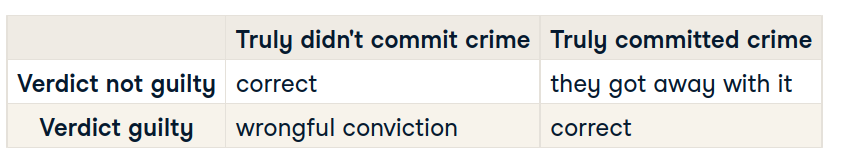

Bunlardan ikisi kararın doğru olduğunu gösterir.

Sanık suçu işlemediği halde suçlu olduğuna karar verilmişse, haksız yere mahkum edilmiştir. Sanık suçu işlemiş ancak karar suçsuz ise, suçu yanına kar kalmıştır. Bunların ikisi de adalette yapılan hatalardır.

Benzer şekilde, hipotez testi için de doğru yapmanın iki yolu ve iki tür hata vardır.

Sıfır hipotezi doğruyken alternatif hipotez desteklenirse, yanlış pozitif hata yapılmış olur. Alternatif hipotez doğruyken boş hipotez desteklenirse, yanlış negatif hata yapılmış olur. Bu hatalar bazen sırasıyla birinci tip ve ikinci tip hatalar olarak bilinir.

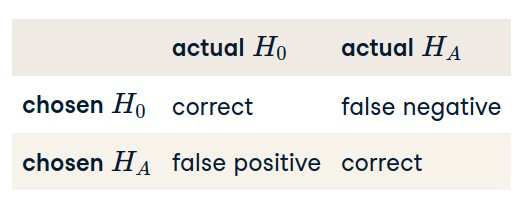

**Yapılan örnekteki olası hatalar**

Veri bilimcilerin çocuk olarak kodlama yapması durumunda, anlamlılık düzeyine eşit veya daha düşük bir p-değeri elde edildiyse ve sıfır hipotezi reddedildiyse, yanlış pozitif bir hata yapılmış olabilir. Veri bilimcilerin daha yüksek oranda çocuk olarak kodlamaya başlandığı düşünmesine rağmen, bu tüm popülasyon için doğru olmayabilir. Tersine, p-değeri anlamlılık düzeyinden büyükse ve sıfır hipotezi reddedilemediyse, yanlış negatif bir hata yapılmış olabilir.

In [10]:
import numpy as np

lower = np.quantile(first_code_boot_distn, 0.025)
upper = np.quantile(first_code_boot_distn, 0.975)
(lower, upper)

(0.3710747456877488, 0.41088014153029634)

* "Popülasyondaki çocuk yaşta kodlamaya başlayanların gerçek oranının %37 ile %41 arasında olduğuna dair %95 güvenimiz var."
* Eğer belirlediğimiz hipotez değeri (0.35) bu aralığın içindeyse, $H_0$ reddedilemez.
* Eğer bu aralığın dışındaysa, $H_0$ reddedilir
* Bizim durumumuzda $H_0$ hipotezimiz reddedilir.

# **t-testlerinin gerçekleştirilmesi tek bir değişken için bir test istatistiği olan z-skorunu hesaplamıştık**

 Bir önceki bölümde, tek bir değişken için bir test istatistiği olan z-skorunu hesaplama anlatılmıştı. 

**İki örneklemli problemler**

* Burada, bir değişkendeki gruplar arasında örnek istatistiklerinin karşılaştırılmasıyla ilgilenilecektir.
* Stack Overflow veri setinde, `converted_comp` sayısal bir yıllık ücret değişkenidir. 
* `age_first_code_cut` ise iki seviyeli kategorik bir değişkendir. Kullanıcının programlamaya ne zaman başladığını tanımlayan çocuk ve yetişkin. 
*  Yaş grubu arasındaki ücrete farklılıkları hakkında sorular sorulabilir. Örneğin, ilk olarak çocukken programlama yapan kullanıcılar, yetişkin olarak başlayanlara göre daha mı iyi ücret alıyor? 

**Hipotezler**

* $H_0:$ Ortalama maaş(ABD Doları cinsinden) ilk olarak çocuk olarak kodlayanlar ve ilk olarak yetişkin olarak kodlayanlar için aynıdır. 
* $H_A:$ Ortalama maaş(ABD Doları cinsinden), önce çocuk olarak kodlayanlar için önce yetişkin olarak kodlayanlara kıyasla daha yüksektir.

$H_0: \mu_{child} = \mu_{adult} ( H_0: \mu_{child} - \mu_{adult} = 0)$

$H_A: \mu_{child} > \mu_{adult} (H_A: \mu_{child} - \mu_{adult} > 0)$

**Test İstatistikleri**

Popülasyon ortalamasını bilinmese de, örneklem ortalaması kullanarak tahmin edilebilir.
bir örneklem ortalamasını belirtmek için kullanılır. Daha sonra örnek ortalamasının hangi gruba karşılık geldiğini belirtmek için alt simgeler kullanılır. Bu iki örneklem ortalaması arasındaki fark, hipotez testi için test istatistiğidir. Daha önce anlatılan z-skorları bir tür standartlaştırılmış test istatistiğidir.

$\bar{x}:$ Örneklem ortalaması

$\bar{x}_{child}:$ Çocuk olarak ilk kodlama için örnek ortalama maaş

$\bar{x}_{adult}:$ Yetişkin olarak ilk kodlama için örnek ortalama maaş

$\bar{x}_{child} -  \bar{x}_{adult}:$ test istatistiği

*z-score:* standartlaştırılmış test istatistiği 

**Test istatistiğinin standartlaştırılması**

*  z-skorları, örneklem istatistiğinin alınması, bu istatistiğin ortalamasının ilgilenilen popülasyon parametresi olarak çıkarılması ve ardından standart hataya bölünmesiyle hesaplanır. İki örneklem durumunda, t olarak gösterilen test istatistiği benzer bir denklem kullanır. İki grup için örneklem istatistikleri arasındaki farkı alır, iki grup arasındaki popülasyon farkı çıkarılır ve ardından standart hataya bölünür.

$z = \frac{\text{samplestat} - \text{populationsparameter}}{\text{standarderror}}$ 

$t = \frac{\text{differenceinsamplestats} - \text{differenceinpopulationparameters}}{\text{standarderror}}$

$t = \frac{(\bar{x}_{child} - \bar{x}_{adult}) - (\mu_{child} - \mu_{adult})}{SE(\bar{x}_{child} - \bar{x}_{adult})}$

**Standart Error**
*  Test istatistiği denkleminin paydası için gerekli olan standart hatayı hespalamak için bootstrapping iyi bir seçenek olma eğilimindedir. Ancak, buna yaklaşmanın daha kolay bir yolu vardır. Örneklemdeki her grup için sayısal değişkenin standart sapması ve her gruptaki gözlem sayısı hesaplanır. Ardından bu değerler denkleme girilir ve sonuç hesaplanır.

$SE(\bar{x}_{child} - \bar{x}_{adult}) \approx \sqrt{\frac{s^2_{child}}{n_{child}} + \frac{s^2_{adult}}{n_{adult}}}$

* s: değişkenin standart sapması

* n: Örneklem boyutu( gözlem sayısı / örneklemdeki satır sayısı)

**Sıfır hipotezinin doğru olduğunu varsayarsak**

$t = \frac{(\bar{x}_{child} - \bar{x}_{adult}) - (\mu_{child} - \mu_{adult})}{SE(\bar{x}_{child} - \bar{x}_{adult})}$

Boş hipotezin doğru olduğu varsayılırsa, yapabilecek bir basitleştirme vardır. Sıfır hipotezi, popülasyon ortalamalarının eşit olduğunu ve aralarındaki farkın sıfır olduğunu varsayar, dolayısıyla paydaki popülasyon terimi kaybolur. Standart hata için yaklaşım eklendiğinde artık yalnızca örnek veri kümesi üzerinden hesaplamalar kullanılarak test istatistiği hesaplanabilir.

$H_0: \mu_{child} - \mu_{adult} = 0$ → $t = \frac{(\bar{x}_{child} - \bar{x}_{adult})}{SE(\bar{x}_{child} - \bar{x}_{adult})}$

$t = \frac{(\bar{x}_{child} - \bar{x}_{adult})}{\sqrt{\frac{s^2_{child}}{n_{child}} + \frac{s^2_{adult}}{n_{adult}}}}$

**Sıfır hipotezinin doğru olduğunu varsayan hesaplamalar**

In [11]:
df_stck.groupby('age_first_code_cut')['converted_comp'].mean() # Bu kod, her iki grup (çocuk/yetişkin) için ortalama maaşları hesaplar.

age_first_code_cut
adult    111313.311047
child    132419.570621
Name: converted_comp, dtype: float64

In [12]:
xbar = df_stck.groupby('age_first_code_cut')['converted_comp'].mean()
xbar # Ortalamalar

age_first_code_cut
adult    111313.311047
child    132419.570621
Name: converted_comp, dtype: float64

In [13]:
s = df_stck.groupby('age_first_code_cut')['converted_comp'].std()
s # Standar sapmalar

age_first_code_cut
adult    271546.521729
child    255585.240115
Name: converted_comp, dtype: float64

In [14]:
n = df_stck.groupby('age_first_code_cut')['converted_comp'].count()
n # Gözlem sayıları

age_first_code_cut
adult    1376
child     885
Name: converted_comp, dtype: int64

In [15]:
# Sonucu topluca hesaplamak için
# Yukarıdaki gibi manuel yazmak bize sonuçların Serie dönmesini sağlerken, aşağıdaki şekilde yapmak DataFrame şeklinde sonuç döner.
df_stck.groupby('age_first_code_cut')['converted_comp'].agg(['mean', 'std', 'count'])

,mean,std,count
age_first_code_cut,,,
adult,111313.311047,271546.521729,1376
child,132419.570621,255585.240115,885


In [16]:
# T değerini hesaplayalım

import numpy as np

pay = xbar.iloc[1] - xbar.iloc[0]
payda = np.sqrt(s.iloc[1]**2 / n.iloc[1] + s.iloc[0]**2 / n.iloc[0])
t_stat = pay /payda
t_stat

1.8699313316221844

**t-dağılımları**

Text(0, 0.5, 'PDF(x)')

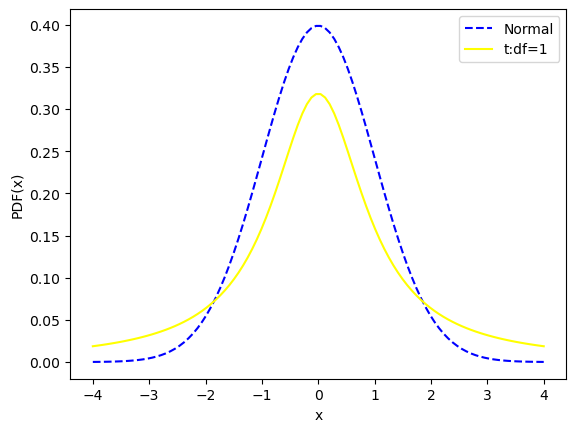

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x), label='Normal', linestyle='--', color='blue')
plt.plot(x, stats.t.pdf(x, 1), label='t:df=1', color='yellow')
plt.legend()
plt.xlabel('x')
plt.ylabel('PDF(x)')

**Degrees Of Freedom**

Serbestlik derecesini artırdıkça, t-dağılımı normal dağılıma yaklaşır. 
Aslında normal dağılım, sonsuz serbestlik derecesine sahip bir t-dağılımıdır.
Serbestlik derecesi, veri örneğindeki mantıksal olarak bağımsız değerlerin maksimum sayısı olarak tanımlanır.
Bu oldukça zor bir kavramdır, bu yüzden bir örnek deneyelim.

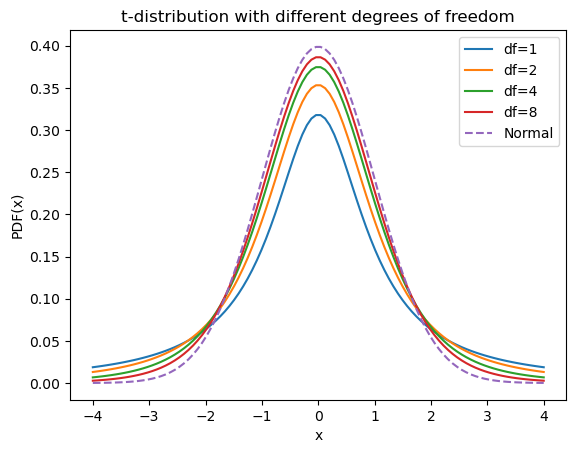

In [18]:
# T dağılımının serbestlik derecesini artırarak normal dağılıma ne kadar yaklaştığını görebiliriz
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x = np.linspace(-4, 4, 100)

# Plot for different degrees of freedom
for df in [1, 2, 4, 8]:
    plt.plot(x, stats.t.pdf(x, df), label=f'df={df}')

plt.plot(x, stats.norm.pdf(x), label='Normal', 
         linestyle='--')
plt.legend()
plt.title('t-distribution with different degrees of freedom')
plt.xlabel('x')
plt.ylabel('PDF(x)')
plt.show()

**Serbestlik Derecelerinin Hesaplanması**

Veri kümemizde 5 bağımsız gözlem olduğunu ve değerlerden dördünün 2, 6, 8 ve 5 olduğunu varsayalım.
Bu bilgiyle, beşinci değer artık bağımsız değildir; 4 olmalıdır.
Örneklemdeki beş gözlemin hepsi bağımsız olsa da, örneklem hakkında ek bir gerçeği bildiğimiz için -aritmetik ortalamsı 5 olduğu için- sadece 4 serbestlik derecesine sahibiz. İki örneklemli durumumuzda, gözlem sayısı kadar serbestlik derecesi vardı, eksi iki çünkü iki örneklem istatistiğini, her grubun ortalamasını biliyoruz.

$df = n_{child} + n_{adult} - 2$

**Hipotezler**

$H_0:$ Ortalama maaş(ABD Doları cinsinden), ilk olarak çocuk olarak kodlayanlar ve ilk olarak yetişkin olarak kodlayanlar için aynıdır.

$H_A:$ Ortalama maaş(ABD Doları cinsinden), ilk olarak çocuk olarak kodlayanlar ve ilk olarak yetişkin olarak kodlayanlara kıyasla daha yüksektir.

Bu bir "daha büyük" alternatif hipotezi olduğundan, sağ kuyruklu bir teste ihtiyaç vardır.

**Significance level**

Şimdi bir p-değeri hesaplayacağız, ancak önce bir anlamlılık düzeyine karar vermemiz gerekiyor. Birkaç olasılık var; 0.1'i kullanalım. Bu, p-değerinin 0.1'den küçük veya ona eşit olması durumunda alternatif lehine boş hipotezi reddedeceğimiz anlamına gelir.

**P-değerinin hesaplanması: bir orana karşı bir değer**

Daha önce, p-değerini elde etmek için z-skoru normal bir CDF ile dönüştürdük. Sağ kuyruklu bir test olduğu için sonucu birden çıkardık. Yine daha önce, örneklem bilgisini kullanarak test istatistiği standart hatası için bir yaklaşım kullanıldı. Bu yaklaşımı kullanmak daha fazla belirsizlik ekler bu yüzden bir z problemi yerine bir t problemidir. t dağılımı, tek bir istatistik hesaplamasında birden fazla tahmin kullanıldığında daha fazla belirsizliğe izin verir. Burada, çoklu tahminler örnek ortalamasına ve örnek standart sapmasına karşılık gelmektedir.

from scipy.stats import norm

1 - norm.cdf(z_score)

* *z-statistics:* Bir popülasyon parametresini tahmin etmek için bir örnek istatistiği kullanırken gereklidir.

* *t-statistics:* Bir popülasyon parametresini tahmin etmek için çoklu örneklem istatistiği kullanırken gereklidir.

**P-değerlerinin hesaplanması: farklı gruplardan iki ortalama**

In [19]:
degrees_of_freedom = n.iloc[0] + n.iloc[1] - 2
degrees_of_freedom

2259

In [20]:
from scipy.stats import t
1 - t.cdf(t_stat, df=degrees_of_freedom)
# t < 0.1=alpha o.i. H0 hipotezi reddedilir
# Çocukken kodlamaya başlayanlar, yetişkinken kodlamaya başlayanlardan daha fazla ücret alıyorlar çıkarımı yapılır 

0.030811302165157595

### Paired T-tests

**Hipotezler**

Sorulardan biri, Cumhuriyetçi adaylara verilen oyların yüzdesinin 2008'de 2012'ye kıyasla daha düşük olup olmadığıdır.
Bunu test etmek için hipotezler oluşturulur. Daha önce olduğu gibi, boş hipotez önsezisinin yanlış olduğu ve nüfus parametresinin her yıl grubunda aynı olduğudur.
Alternatif hipotez ise 2008'deki parametrenin 2012'dekinden daha düşük olduğudur. Anlamlılık düzeyi 0.05'dir. Bu veri setinin bir özelliği, 2008 ve 2012 oylarının eşleştirilmiş olmasıdır, yani her ikisi de aynı ilçeye atıfta bulunduğu için bağımsız değildirler. Bu, oy verme modellerinin ilçe düzeyindeki demografik özellikler ve yerel politikalar nedeniyle oluşabileceği anlamına gelir ve modelde de bu eşleştirme yakalanmak istenmektedir.

$H_0: \mu_{2008} - \mu_{2012} = 0$

$H_A: \mu_{2008} - \mu_{2012} < 0$


In [21]:
import pandas as pd

df_election = pd.read_feather("resources/repub_votes_potus_08_12.feather")
df_election

,state,county,repub_percent_08,repub_percent_12
0,Alabama,Hale,38.957877,37.139882
1,Arkansas,Nevada,56.726272,58.983452
2,California,Lake,38.896719,39.331367
3,California,Ventura,42.923190,45.250693
4,Colorado,Lincoln,74.522569,73.764757
...,...,...,...,...
95,Wisconsin,Burnett,48.342541,52.437478
96,Wisconsin,La Crosse,37.490904,40.577038
97,Wisconsin,Lafayette,38.104967,41.675050
98,Wyoming,Weston,76.684241,83.983328


$H_0:$ 2008 ve 2012 yıllarındaki oy oranları eşittir

$H_1:$ 2008 < 2012 yıllarındaki oy oranları

- Anlamlılık düzeyi 0.05'tir

- Aradaki oy farkı istatistiksel olarak anlamlı mı değil mi?

**İki örnekten bir örneğe**

Eşleştirilmiş analizeler için, iki değişkeni ayrı ayrı ele almak yerine, farkın tek bir değişkeni ele alınabilir. Bu, diff adlı bir sütunla birlikte sample_data adlı bir DataFrame'de saklanır. Farkın bu histogramında, çoğu değer eksi on ile on arasındadır ve en az bir aykırı değer vardır.

In [22]:
sample_data = df_election.copy()

sample_data['diff'] = sample_data['repub_percent_08'] - \
sample_data['repub_percent_12']

sample_data

,state,county,repub_percent_08,repub_percent_12,diff
0,Alabama,Hale,38.957877,37.139882,1.817995
1,Arkansas,Nevada,56.726272,58.983452,-2.257179
2,California,Lake,38.896719,39.331367,-0.434648
3,California,Ventura,42.923190,45.250693,-2.327503
4,Colorado,Lincoln,74.522569,73.764757,0.757812
...,...,...,...,...,...
95,Wisconsin,Burnett,48.342541,52.437478,-4.094937
96,Wisconsin,La Crosse,37.490904,40.577038,-3.086134
97,Wisconsin,Lafayette,38.104967,41.675050,-3.570083
98,Wyoming,Weston,76.684241,83.983328,-7.299087


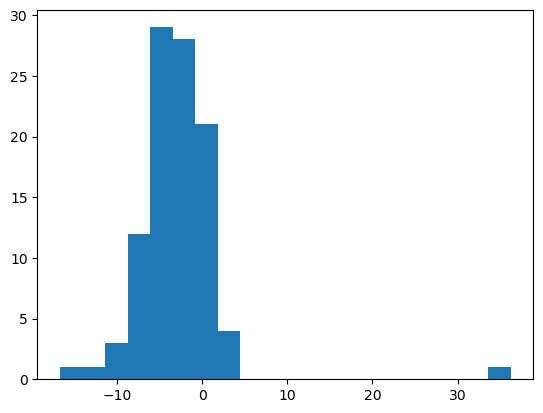

In [30]:
plt.hist(sample_data['diff'], bins=20);

**Revize Edilmiş Hipotezler**

Hipotezler, tek popülasyon ortalamasının, $\mu_{diff}$'in, sıfıra eşit veya sıfırdan küçük olması açısından yeniden ifade edilebilir. Test istatistiği, t, iki örneklemli duruma kıyasla biraz daha basit bir denkleme sahiptir. Tek bir istatistik vardır, bu nedenle serbestlik derecesi sayısı, çift sayısı eksi birdir.

$H_0: \mu_{diff} = 0$

$H_A: \mu_{diff} < 0$

$t = \frac{(\bar{x}_{diff} - \mu_{diff})}{\sqrt{\frac{s^2_{diff}}{n_{diff}}}}$

$df = n - 1$ (Tek istatistik durumunda serbestlik derecesi hesaplanması)

$df = {n}_{1} + {n}_{2} - 2$ (İki istatistik durumunda serbestlik derecesi hesaplanması)

In [24]:
# Farkın örnek istatistiklerini hesapla

x_bar_diff = sample_data['diff'].mean()

x_bar_diff

-2.877109041242944

In [25]:
import numpy as np

n_diff = len(sample_data)

s_diff = sample_data['diff'].std()

t_stat = (x_bar_diff -0) / np.sqrt(s_diff**2 / n_diff)

In [26]:
t_stat

-5.601043121928489

**p-değerinin hesaplanması**

In [27]:
degrees_of_freedom = n_diff - 1
p_value = t.cdf(t_stat, df=degrees_of_freedom)
p_value

9.572537285272411e-08

##### ttest kullanarak ortalama arasındaki farkları test etme

In [28]:
import pingouin

pingouin.ttest(x=sample_data['repub_percent_08'],
               y=sample_data['repub_percent_12'], paired=True,
               alternative='less')

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-5.601043,99,less,9.572537e-08,"[-inf, -2.02]",0.217364,1.323e+05,0.696338


**Unpaired ttest()**

Eşleştirilmiş seçeneğini doğru olarak ayarlamazsak ve bunun yerine eşleştirilmemiş bir t-testi yaparsak, sayılar değişir. Test istatistiği sıfıra daha yakındır, daha fazla serbestlik derecesi vardır ve p-değeri çok daha büyüktür. Verilerimiz eşleştirilmişken, eşleştirilmemiş bir t-testi yapmak yanlış negatif hata olasılığını artırır.

In [29]:
pingouin.ttest(x=sample_data['repub_percent_08'],
               y=sample_data['repub_percent_12'], paired=False,
               alternative='less')

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.536997,198,less,0.062945,"[-inf, 0.22]",0.217364,0.927,0.454972
